# Storylines simulations

**Further material:**   
- In the [Climate DT user guide](https://platform.destine.eu/services/documents-and-api/doc/?service_name=climate-dt-user-guide) navigate to "Simulations" -> "Storyline Simulations".
- Publication by John et al. 2026 [Global Kilometer-Scale Cliamte STorylines Using Spectral Nudging](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2025MS005326)
- [ECMWF parameter database](https://codes.ecmwf.int/grib/param-db/)


In [ ]:
import earthkit.data as ekd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
import numpy as np

### 1. Finding and requesting the storylines data

**Task:**
We want to request the following data: The storylines simulation ensemble member 1 for the present, past and future climate for July 2025 (e.g. 12 UTC). We are insterested in the 2m temperature (param: 167). Create a matching request for this data using the user guide experiment ID as helper.

**Reminder:**
The request keys can be found in [the data keys overview](../04_Cheatsheets/data_keys.rst).

In [24]:
request = {
     'activity': 'story-nudging',
     'class': 'd1',
     'dataset': 'climate-dt',
     'experiment': 'hist',
     'expver': '0001',
     'model': 'ifs-fesom',
     'generation': '2',
     'realization': '1',
     'resolution': 'high',
     'date': '20250701/to/20250731',
     'time': '1200',
     'stream': 'clte',
     'type': 'fc',
     'levtype': 'sfc',
     'param': '167'
}

**Task** Reduce the region so that it covers only Finland. E.g. latitude: 59 to 71 degree and longitude: 19 to 32 degree.

In [70]:
request_finland = request | {
    "feature": {
        "type": "boundingbox",
        "points" : [[59, 19], [71, 32]],
    },
}

**Task:** Find out on which data-bridge the data is located and request the data.

In [78]:
data =  ekd.from_source("polytope", "destination-earth", request_finland, stream=False, \
                               address='polytope.mn5.apps.dte.destination-earth.eu')

2026-06-01 17:37:50 - INFO - Key read from /home/kiszlert/.polytopeapirc
2026-06-01 17:37:50 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20250701/to/20250731\n'
            'experiment: hist\n'
            "expver: '0001'\n"
            'feature:\n'
            '  points:\n'
            '  - - 59\n'
            '    - 19\n'
            '  - - 71\n'
            '    - 32\n'
            '  type: boundingbox\n'
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: ifs-fesom\n'
            "param: '167'\n"
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '1200'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-06-01 17:37:50 - INFO - Polytope user key found in session cache for user kiszlert


2026-06-01 17:37:51 - INFO - Request accepted. Please poll ./fb4e56bd-9710-487f-aa5a-e34918824029 for status
2026-06-01 17:37:51 - INFO - Polytope user key found in session cache for user kiszlert
2026-06-01 17:37:51 - INFO - Checking request status (fb4e56bd-9710-487f-aa5a-e34918824029)...
2026-06-01 17:37:52 - INFO - The current status of the request is 'queued'
2026-06-01 17:37:52 - INFO - The current status of the request is 'processing'
2026-06-01 17:38:02 - INFO - The current status of the request is 'processed'


In [79]:
data

CovjsonReader(/tmp/tmpj2jyxzp3/polytope-9711006338e793160f8fe537c7adf2c6b8482fcd809d5d0b74eb2496fa0379e9.cache)

**Task:** Convert the data to xarray.

In [82]:
ds = data.to_xarray()
ds

<xarray.Dataset> Size: 1MB
Dimensions:    (datetimes: 31, number: 1, steps: 1, points: 5050)
Coordinates:
  * datetimes  (datetimes) <U20 2kB '2025-07-01T12:00:00Z' ... '2025-07-31T12...
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 40kB 0 1 2 3 4 5 ... 5044 5045 5046 5047 5048 5049
    latitude   (points) float64 40kB 59.01 59.01 59.01 59.01 ... 71.0 71.0 71.0
    longitude  (points) float64 40kB 21.09 20.55 20.82 ... 24.13 27.61 20.65
    levelist   (points) float64 40kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    2t         (datetimes, number, steps, points) float64 1MB 284.6 ... 284.6
Attributes: (12/16)
    activity:       story-nudging
    class:          d1
    dataset:        climate-dt
    Forecast date:  2025-07-01T12:00:00Z
    experiment:     hist
    expver:         0001
    ...             ...
    resolution:     high
    stream:         clte
    type:           fc
    number:         0
    step:           0
    date:           2025-07-01T12:00:00Z

### 2. Plotting the healpix data

There are different options to plot the healpix data for regional areas. Here we show two possible options with cartopy.

**Scatter plot:** Select which data to plot and directly plot the data point by point. This is not the pretiest way, but gives exactly the data at the point which it is assigned to.

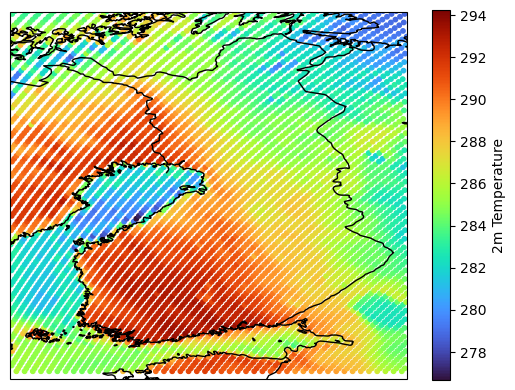

In [83]:
da = ds.isel(datetimes=0, number=0, steps=0)  # pick one time step

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([19, 32, 59, 71])  # Finland bounds

sc = ax.scatter(da.longitude, da.latitude, c=da.values(),
                  transform=ccrs.PlateCarree(), s=10, cmap='turbo')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
plt.colorbar(sc, ax=ax, label='2m Temperature')
#plt.title(str(da.datetimes.values))
plt.show()


**Simple interpolated pcolormesh:** You can use scipy to regrid the data to a specified combination of points.

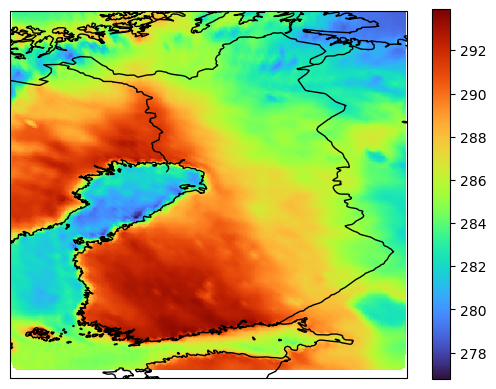

In [84]:
da = ds.isel(datetimes=0, number=0, steps=0)  # pick one time step

lons, lats, vals = da.longitude.values, da.latitude.values, da['2t'].values

lat_g = np.linspace(59, 71, 300)
lon_g = np.linspace(19, 32, 300)
lo, la = np.meshgrid(lon_g, lat_g)
vals_grid = griddata((lons, lats), vals, (lo, la), method='linear')

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([19, 32, 59, 71])
pcm = ax.pcolormesh(lon_g, lat_g, vals_grid, transform=ccrs.PlateCarree(), cmap='turbo')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
plt.colorbar(pcm, ax=ax)
plt.show()

Now we have a figure but we don't know what lon-lat resolution this actually is. Therefore, we can choose another option where we use the regridding functionality in earthkit-regrid. For this we first need to download the data.

In [ ]:
import earthkit.regrid as ekr

output_path="../data/storylines_test.grib"
# Now we save the data we have been working with to a file
data.to_target("file", output_path) # this does not work unfortunately and gives a not implemented error

NotImplementedError: 